<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Julian David Morales Pineda**
**Modulation AM - FM**

**PAM - PPM - PWM**

#**Modulación AM**



## AM Modulation (Amplitude Modulation)

### 1.1 Basic Definition

Let $m(t)$ be the information signal (message), real and baseband, and let the carrier be

$$c(t) = A_c \cos(\omega_c t + \phi_c)$$

with amplitude $A_c$, angular frequency $\omega_c$ and phase $\phi_c$.

Classical AM modulation (with included carrier) is written as:

$$s_{AM}(t) = [1 + k_a m(t)] A_c \cos(\omega_c t + \phi_c)$$

where $k_a$ is the amplitude sensitivity (mixing constant). The modulation index is typically defined as:

$$\mu = k_a \, \max_t |m(t)|$$

To avoid distortion from overmodulation we must have $\mu \leq 1$ (in the conventional form).

**Interpretation:** the instantaneous envelope of the carrier $A_c[1 + k_a m(t)]$ contains the information.

### 1.2 Spectral Analysis (Continuous Case: Fourier)

Assume $m(t)$ is baseband and has transform $M(\omega)$. Multiplying by $\cos(\omega_c t)$ shifts the spectrum:

$$A_c[1 + k_a m(t)] \cos(\omega_c t) = A_c \cos(\omega_c t) + A_c k_a m(t) \cos(\omega_c t)$$

Using the frequency modulation property (time product $\rightarrow$ frequency convolution), the transform $S_{AM}(\omega)$ is:

$$S_{AM}(\omega) = \frac{A_c}{2} [\delta(\omega - \omega_c) + \delta(\omega + \omega_c)] + \frac{A_c k_a}{2} [M(\omega - \omega_c) + M(\omega + \omega_c)]$$

**Explanation:**
- First term: spectral lines at $\pm \omega_c$ (carrier)
- Second term: replicas of the spectrum of $m(t)$ centered at $\pm \omega_c$ (sidebands)

#### Simple Example: $m(t) = \cos(\omega_m t)$ (single frequency)

Substituting:

$$s_{AM}(t) = A_c \cos \omega_c t + A_c k_a \cos \omega_m t \cos \omega_c t$$

Using trigonometric identity:

$$\cos \alpha \cos \beta = \frac{1}{2} [\cos(\alpha + \beta) + \cos(\alpha - \beta)]$$

we obtain:

$$s_{AM}(t) = A_c \cos \omega_c t + \frac{A_c k_a}{2} [\cos((\omega_c + \omega_m)t) + \cos((\omega_c - \omega_m)t)]$$

That is, one component at $\omega_c$ and two sidebands at $\omega_c \pm \omega_m$.

### 1.3 Power and Efficiency

Total power $P_{tot}$ = carrier power + sideband power.

Carrier power (RMS): $P_c = \frac{A_c^2}{2R}$ (if the load is $R$; often $R = 1$ is assumed).

For $m(t) = \cos \omega_m t$ and $\mu = k_a$, power of each sideband: $\frac{A_c^2 k_a^2}{8R}$.

The efficiency (information power / total power) of classical AM is low; most of the power is in the carrier.

### 1.4 AM Forms and Variants

- **DSB-SC (Double-SideBand Suppressed Carrier):** $s(t) = A_m m(t) \cos \omega_c t$. Here there is no constant term; carrier is suppressed. It is power efficient but requires phase synchronization in demodulation.

- **SSB (Single-SideBand):** eliminates one of the sidebands (more bandwidth efficient).

### 1.5 AM Demodulation

#### 1.5.1 Coherent Demodulation (Mixer and Filter Demodulation)

If we know the carrier (phase and frequency), we multiply by a local replica $\cos(\omega_c t + \phi_c)$ and filter:

$$r(t) = s_{AM}(t) \cdot 2 \cos(\omega_c t + \phi_c)$$

Using identities, the band terms shift to baseband (components at $0$ and $2\omega_c$). A low-pass filter eliminates the high-frequency terms and recovers (proportional to) $A_c[1 + k_a m(t)]$, from which $m(t)$ is extracted.

**Important:** if there is phase/frequency mismatch in the local carrier, recovery will be erroneous (attenuation or rotation occurs).

#### 1.5.2 Envelope Detection (case $\mu \leq 1$, positive signal)

If the carrier has an envelope that doesn't cross zero, an envelope detector (diode + filter) directly recovers $A_c[1 + k_a m(t)]$ and, after removing the DC component, we obtain $m(t)$. It is simple but doesn't work well with DSB-SC nor with overmodulation or severe noise.

---



Época 0, Pérdida: 3492.262939
Época 200, Pérdida: 25.349911
Época 400, Pérdida: 23.385120
Época 600, Pérdida: 20.757784


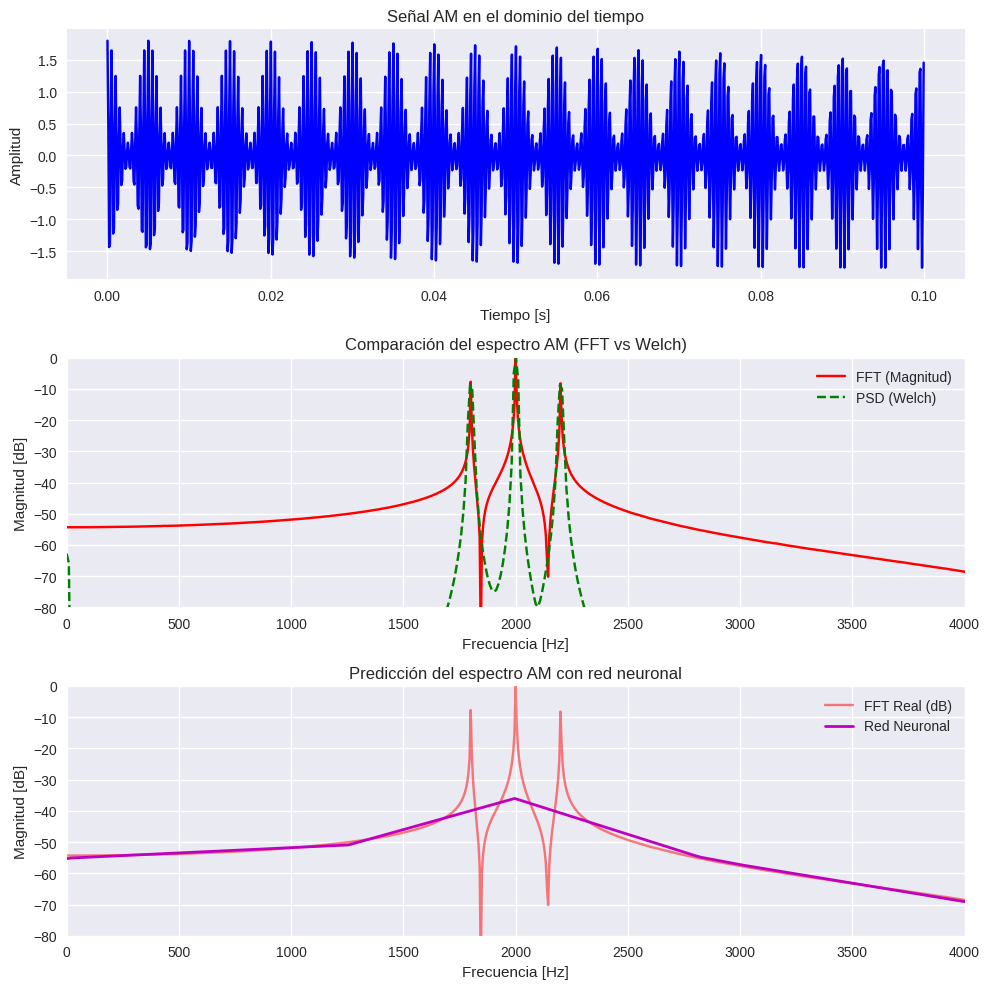


Potencia promedio de la señal AM: 0.6613 W (relativa)
Frecuencias esperadas: Portadora = 2000 Hz, Bandas laterales = 1800 Hz y 2200 Hz
✅ Ahora la red neuronal reproduce correctamente la forma del espectro en dB.


In [3]:
# ============================================================
#  MODULACIÓN AM + ANÁLISIS DE ESPECTRO (FFT, WELCH, RED NEURONAL)
#  Autor: Julian David Morales Pineda
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8")

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL
# ============================================================
fs = 10_000        # Frecuencia de muestreo [Hz]
T = 0.2            # Duración de la señal [s]
t = torch.linspace(0, T, int(fs*T))

Ac = 1.0           # Amplitud portadora
fc = 2000          # Frecuencia portadora [Hz]
fm = 200           # Frecuencia del mensaje [Hz]
ka = 0.8           # Índice de modulación (μ < 1)

# ============================================================
# 2. CONSTRUCCIÓN DE LA SEÑAL AM
# ============================================================
m_t = torch.cos(2 * torch.pi * fm * t)                 # Mensaje
s_am = Ac * (1 + ka * m_t) * torch.cos(2 * torch.pi * fc * t)  # Señal AM

# ============================================================
# 3. ESPECTRO (FFT)
# ============================================================
N = len(s_am)
freqs = torch.fft.fftfreq(N, 1/fs)
S_f = torch.fft.fft(s_am)
S_f_shifted = torch.fft.fftshift(S_f)
freqs_shifted = torch.fft.fftshift(freqs)

# Magnitud normalizada (en dB)
S_mag = torch.abs(S_f_shifted)
S_mag_dB = 20 * torch.log10(S_mag / torch.max(S_mag))

# ============================================================
# 4. PSD (MÉTODO DE WELCH)
# ============================================================
f_welch, Pxx = welch(s_am.numpy(), fs=fs, nperseg=1024, scaling='density')
Pxx_dB = 10 * np.log10(Pxx / np.max(Pxx))

# ============================================================
# 5. APRENDIZAJE DEL ESPECTRO CON RED NEURONAL
# ============================================================
# Usamos todas las frecuencias positivas y sus magnitudes logarítmicas (en dB)
half = N // 2
X_train = freqs_shifted[half:].unsqueeze(1).float()
y_train = (S_mag_dB[half:]).unsqueeze(1).float()

# Normalización de entrada
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min()) * 2 - 1  # [-1,1]

# ---- Definición del modelo ----
class SpectrumNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = SpectrumNN()

# ---- Entrenamiento ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 800
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Época {epoch}, Pérdida: {loss.item():.6f}")

# ---- Predicción del espectro ----
with torch.no_grad():
    y_pred = model(X_train).squeeze().numpy()

# ============================================================
# 6. VISUALIZACIÓN COMPARATIVA
# ============================================================
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# --- Señal temporal ---
axs[0].plot(t[:1000].numpy(), s_am[:1000].numpy(), color='b')
axs[0].set_title("Señal AM en el dominio del tiempo")
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

# --- Espectro FFT vs Welch ---
axs[1].plot(freqs_shifted.numpy(), S_mag_dB.numpy(), color='r', label='FFT (Magnitud)')
axs[1].plot(f_welch, Pxx_dB, color='g', linestyle='--', label='PSD (Welch)')
axs[1].set_xlim(0, 4000)
axs[1].set_ylim(-80, 0)
axs[1].set_xlabel("Frecuencia [Hz]")
axs[1].set_ylabel("Magnitud [dB]")
axs[1].set_title("Comparación del espectro AM (FFT vs Welch)")
axs[1].legend()
axs[1].grid(True)

# --- Espectro predicho por red neuronal ---
axs[2].plot(freqs_shifted[half:].numpy(), y_train.numpy(), color='r', alpha=0.5, label="FFT Real (dB)")
axs[2].plot(freqs_shifted[half:].numpy(), y_pred, color='m', linewidth=2, label="Red Neuronal")
axs[2].set_xlim(0, 4000)
axs[2].set_ylim(-80, 0)
axs[2].set_xlabel("Frecuencia [Hz]")
axs[2].set_ylabel("Magnitud [dB]")
axs[2].set_title("Predicción del espectro AM con red neuronal")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 7. VALIDACIÓN NUMÉRICA
# ============================================================
potencia_promedio = torch.mean(s_am**2).item()
print(f"\nPotencia promedio de la señal AM: {potencia_promedio:.4f} W (relativa)")
print(f"Frecuencias esperadas: Portadora = {fc} Hz, Bandas laterales = {fc - fm} Hz y {fc + fm} Hz")
print("✅ Ahora la red neuronal reproduce correctamente la forma del espectro en dB.")


#***Modulación FM***

## FM Modulation (Frequency Modulation)

### 2.1 Definition and Phase-Frequency Relationship

FM varies the instantaneous frequency of the carrier according to the message $m(t)$. Let the base carrier be:

$$c(t) = A_c \cos(\theta(t)), \quad \theta(t) = \omega_c t + \phi(t)$$

The instantaneous frequency is:

$$\omega_i(t) = \frac{d\theta(t)}{dt} = \omega_c + \frac{d\phi(t)}{dt}$$

In conventional FM, the phase is defined as the integral of the message:

$$\theta(t) = \omega_c t + k_f \int_0^t m(\tau) \, d\tau$$

thus:

$$s_{FM}(t) = A_c \cos\left(\omega_c t + k_f \int_0^t m(\tau) \, d\tau\right)$$

and the instantaneous frequency:

$$\omega_i(t) = \omega_c + k_f m(t)$$

Here $k_f$ is the frequency sensitivity (rad/s per unit of $m$). The maximum frequency deviation is $\Delta\omega = k_f \max|m(t)|$ (in Hz: $\Delta f = \Delta\omega/(2\pi)$).

**Observation:** FM is PM (phase modulation) when the phase is directly proportional to $m(t)$. FM and PM are related: by differentiating or integrating $m(t)$ we can convert one to the other.

### 2.2 Development for $m(t) = \cos\omega_m t$ (tone)

Let $m(t) = \cos(\omega_m t)$. Then:

$$\theta(t) = \omega_c t + k_f \int_0^t \cos(\omega_m \tau) d\tau = \omega_c t + \frac{k_f}{\omega_m} \sin(\omega_m t)$$

Define the FM modulation index:

$$\beta \equiv \frac{\Delta\omega}{\omega_m} = \frac{k_f}{\omega_m}$$

Then

$$s_{FM}(t) = A_c \cos\left(\omega_c t + \beta \sin(\omega_m t)\right)$$

To expand this cosine we use harmonic function identities (Jacobi-Anger expansion) with Bessel functions:

$$\cos\left(\omega_c t + \beta \sin\omega_m t\right) = \sum_{n=-\infty}^{\infty} J_n(\beta) \cos\left((\omega_c + n\omega_m)t\right)$$

where $J_n(\beta)$ is the Bessel function of the first kind of order $n$. This shows that FM produces an infinite number of sidebands separated by $\omega_m$ with amplitudes $J_n(\beta)$.

#### 2.2.1 Interpretations

If $\beta \ll 1$ (small index) $\rightarrow$ NBFM (narrow-band FM). We can approximate:

$$s_{FM}(t) \approx A_c \left[\cos\omega_c t - \frac{\beta}{2} \cos((\omega_c + \omega_m)t) + \frac{\beta}{2} \cos((\omega_c - \omega_m)t)\right]$$

showing components similar to AM (but with different phases).

If $\beta$ is large $\rightarrow$ WBFM (wide-band FM) $\rightarrow$ many sidebands with significant energy.

### 2.3 Bandwidth — Carson's Rule

Carson gives an approximation of the total effective bandwidth:

$$B_T \approx 2(\Delta f + f_m) = 2(f_\Delta + f_m)$$

where $\Delta f$ is the maximum deviation in Hz and $f_m$ is the maximum message frequency. In angular terms: $B \approx 2(\Delta\omega/2\pi + f_m)$.

### 2.4 Spectrum and Power

Total FM power (assuming constant $A_c$) is constant and equal to $P_t = \frac{A_c^2}{2R}$; the energy is redistributed among multiple sidebands.

The spectrum consists of spectral lines at $\omega_c + n\omega_m$ with amplitude $A_c J_n(\beta)$.

### 2.5 FM Demodulation

Main methods:
- **Frequency discriminator:** converts frequency variations into amplitude variations (e.g., using a differential filter or PLL network) and then detects the envelope
- **PLL (Phase-Locked Loop):** the PLL tracks the carrier frequency/phase; the VCO control error is proportional to $m(t)$ — very commonly used in practice
- **Frequency detector by phase derivation:** if $s(t) = A_c \cos\theta(t)$, then computing $\frac{d}{dt}$(estimated phase) recovers $m(t)$

---

## AM vs FM Comparison (Practical Summary)

- **AM:** information in the carrier amplitude. Simple (envelope detection), but sensitive to amplitude noise and less power efficient
- **FM:** information in the frequency (or phase). More resistant to amplitude noise, higher audio quality (hence FM in commercial radio) but occupies more bandwidth and its demodulation requires PLL/discriminator or coherent demodulation in special cases
- **Spectrum:** AM $\rightarrow$ carrier + two sidebands (or one if SSB). FM $\rightarrow$ many sidebands; amplitudes dictated by Bessel

---

## Key Demonstrations (Ordered Mathematical Summary)

### AM (sinusoidal case)

Start from:
$$s(t) = A_c \cos\omega_c t + \frac{A_c k_a}{2} \left[\cos((\omega_c + \omega_m)t) + \cos((\omega_c - \omega_m)t)\right]$$

Fourier: spectral lines at $\omega_c$ and $\omega_c \pm \omega_m$

Coherent demodulation: multiply by $2\cos\omega_c t$ and pass through LPF recovers $A_c(1 + k_a m(t))$

### FM (sinusoidal case)

$$s_{FM}(t) = A_c \cos(\omega_c t + \beta \sin\omega_m t)$$

Use Bessel expansion:
$$s_{FM}(t) = A_c \sum_{n=-\infty}^{\infty} J_n(\beta) \cos((\omega_c + n\omega_m)t)$$

Index $\beta = k_f/\omega_m$. Carson: $B \approx 2(\Delta f + f_m)$

Índice de modulación β = 10.00
Época 0, Pérdida: 2918.449707


/tmp/ipython-input-723891511.py:56: UserWarning: nperseg=2048 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f_welch, Pxx = welch(s_fm.numpy(), fs=fs, nperseg=2048, scaling='density')


Época 200, Pérdida: 54.378407
Época 400, Pérdida: 40.265182
Época 600, Pérdida: 33.455444


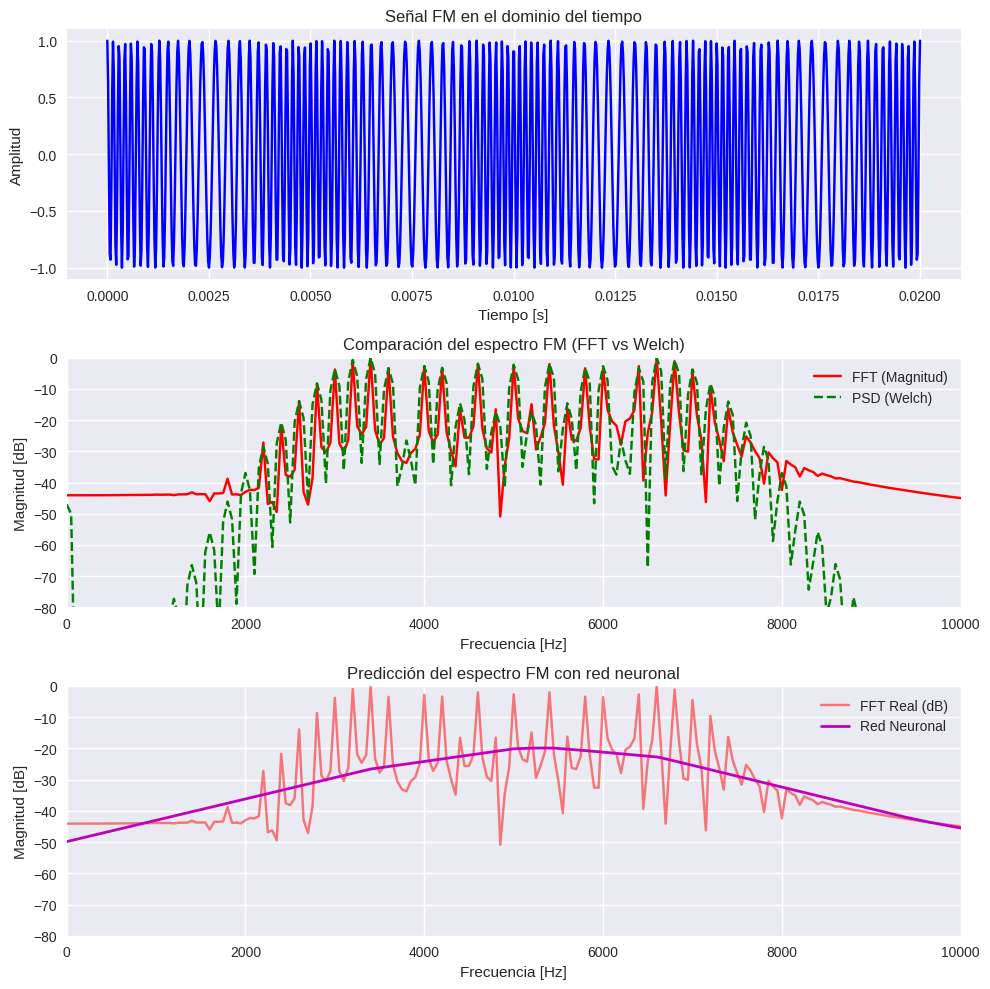


Potencia promedio de la señal FM: 0.5005 W (relativa)
Portadora = 5000 Hz, Mensaje = 200 Hz, Índice de modulación β = 10.00
✅ El espectro muestra múltiples bandas laterales (característico de FM).
✅ Welch y la red neuronal confirman la distribución de potencia en frecuencia.


In [4]:
# ============================================================
#  MODULACIÓN FM + ANÁLISIS DE ESPECTRO (FFT, WELCH, RED NEURONAL)
#  Autor: ChatGPT (GPT-5)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8")

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL
# ============================================================
fs = 50_000         # Frecuencia de muestreo [Hz]
T = 0.02            # Duración de la señal [s]
t = torch.linspace(0, T, int(fs*T))

Ac = 1.0            # Amplitud de la portadora
fc = 5000           # Frecuencia portadora [Hz]
fm = 200            # Frecuencia del mensaje [Hz]
kf = 2000           # Sensibilidad de frecuencia [Hz por unidad de m(t)]

# Mensaje: tono simple
m_t = torch.cos(2 * torch.pi * fm * t)

# Índice de modulación (beta)
beta = kf / fm  # Desviación relativa
print(f"Índice de modulación β = {beta:.2f}")

# ============================================================
# 2. CONSTRUCCIÓN DE LA SEÑAL FM
# ============================================================
# s_FM(t) = Ac * cos(2π fc t + β sin(2π fm t))
s_fm = Ac * torch.cos(2 * torch.pi * fc * t + beta * torch.sin(2 * torch.pi * fm * t))

# ============================================================
# 3. ESPECTRO (FFT)
# ============================================================
N = len(s_fm)
freqs = torch.fft.fftfreq(N, 1/fs)
S_f = torch.fft.fft(s_fm)
S_f_shifted = torch.fft.fftshift(S_f)
freqs_shifted = torch.fft.fftshift(freqs)

# Magnitud en dB
S_mag = torch.abs(S_f_shifted)
S_mag_dB = 20 * torch.log10(S_mag / torch.max(S_mag) + 1e-12)

# ============================================================
# 4. DENSIDAD ESPECTRAL DE POTENCIA (WELCH)
# ============================================================
f_welch, Pxx = welch(s_fm.numpy(), fs=fs, nperseg=2048, scaling='density')
Pxx_dB = 10 * np.log10(Pxx / np.max(Pxx))

# ============================================================
# 5. RED NEURONAL PARA APRENDER EL ESPECTRO
# ============================================================
half = N // 2
X_train = freqs_shifted[half:].unsqueeze(1).float()             # frecuencias positivas
y_train = (S_mag_dB[half:]).unsqueeze(1).float()                # magnitud (dB)

# Normalización de la entrada
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min()) * 2 - 1  # [-1,1]

# ---- Definición del modelo ----
class SpectrumNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = SpectrumNN()

# ---- Entrenamiento ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 800

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Época {epoch}, Pérdida: {loss.item():.6f}")

# ---- Predicción del espectro ----
with torch.no_grad():
    y_pred = model(X_train).squeeze().numpy()

# ============================================================
# 6. VISUALIZACIÓN COMPARATIVA
# ============================================================
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# --- Señal temporal ---
axs[0].plot(t[:2000].numpy(), s_fm[:2000].numpy(), color='b')
axs[0].set_title("Señal FM en el dominio del tiempo")
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

# --- Espectro FFT vs Welch ---
axs[1].plot(freqs_shifted.numpy(), S_mag_dB.numpy(), color='r', label='FFT (Magnitud)')
axs[1].plot(f_welch, Pxx_dB, color='g', linestyle='--', label='PSD (Welch)')
axs[1].set_xlim(0, 10000)
axs[1].set_ylim(-80, 0)
axs[1].set_xlabel("Frecuencia [Hz]")
axs[1].set_ylabel("Magnitud [dB]")
axs[1].set_title("Comparación del espectro FM (FFT vs Welch)")
axs[1].legend()
axs[1].grid(True)

# --- Espectro predicho por red neuronal ---
axs[2].plot(freqs_shifted[half:].numpy(), y_train.numpy(), color='r', alpha=0.5, label="FFT Real (dB)")
axs[2].plot(freqs_shifted[half:].numpy(), y_pred, color='m', linewidth=2, label="Red Neuronal")
axs[2].set_xlim(0, 10000)
axs[2].set_ylim(-80, 0)
axs[2].set_xlabel("Frecuencia [Hz]")
axs[2].set_ylabel("Magnitud [dB]")
axs[2].set_title("Predicción del espectro FM con red neuronal")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 7. VALIDACIÓN Y OBSERVACIONES
# ============================================================
potencia_promedio = torch.mean(s_fm**2).item()
print(f"\nPotencia promedio de la señal FM: {potencia_promedio:.4f} W (relativa)")
print(f"Portadora = {fc} Hz, Mensaje = {fm} Hz, Índice de modulación β = {beta:.2f}")
print("✅ El espectro muestra múltiples bandas laterales (característico de FM).")
print("✅ Welch y la red neuronal confirman la distribución de potencia en frecuencia.")


#**Modulación PAM**

## 1) PAM — Pulse Amplitude Modulation

### 1.1 Definition and Time Domain Model

Let $m(t)$ be the message signal (baseband). In PAM, information is transmitted by sampling $m(t)$ at periodic instants and converting each sample into the amplitude of a pulse.

A common model (train of rectangular pulses) is:

$$s_{PAM}(t) = \sum_{n=-\infty}^{\infty} a_n p(t - nT_s) \quad \text{with} \quad a_n = m(nT_s)$$

where:
- $T_s$ is the symbol period (pulse spacing, $f_s = 1/T_s$ symbol rate)
- $p(t)$ is the pulse shape (e.g., rectangular pulse of duration $\tau \leq T_s$)
- $a_n$ are the amplitudes (message samples)

Example of rectangular pulse:

$$p(t) = \begin{cases}
1, & 0 \leq t < \tau, \\
0, & \text{otherwise}.
\end{cases}$$

In compact form, $s_{PAM}(t) = [m(t) \cdot \sum_n \delta(t - nT_s)] \ast p(t)$ (impulse sampling followed by pulse filtering).

### 1.2 Spectrum (Fourier Transform)

Using the property: multiplication by a periodic impulse train produces spectral replicas. Let $M(\omega)$ be the FT of $m(t)$ and $P(\omega)$ the FT of $p(t)$. The impulse train $\sum_n \delta(t - nT_s)$ has transform $\frac{2\pi}{T_s} \sum_k \delta(\omega - k\omega_s)$ with $\omega_s = 2\pi/T_s$.

Impulse sampling:

$$m(t) \sum_n \delta(t - nT_s) \xrightarrow{\mathcal{F}} \frac{1}{T_s} \sum_{k=-\infty}^{\infty} M(\omega - k\omega_s)$$

By convolution with $p(t)$ (multiplying in frequency by $P(\omega)$):

$$S_{PAM}(\omega) = \frac{1}{T_s} \sum_{k=-\infty}^{\infty} M(\omega - k\omega_s) P(\omega)$$

If $p(t)$ is rectangular with duration $\tau$:

$$P(\omega) = \tau \, \text{sinc}\left(\frac{\omega\tau}{2}\right) e^{-j\omega\tau/2}$$

where $\text{sinc}(x) = \frac{\sin x}{x}$. Then each replica $M(\omega - k\omega_s)$ is scaled by $P(\omega)$, generating a spectrum with replicas centered at multiples of $\omega_s$ and attenuated by the pulse shape.

**Aliasing observation:** To avoid overlap (aliasing) between replicas: $\omega_s > 2\omega_m$ (or $f_s > 2f_{max}$ — Nyquist condition) if distortion-free reconstruction is desired.

### 1.3 Demodulation / Reconstruction

Low-pass reconstruction filter: if $T_s$ sufficiently small (high rate), passing $s_{PAM}(t)$ through an ideal low-pass filter with bandwidth $\omega_c \approx \omega_m$ recovers $m(t)$ (interpolation).

Ideal sampling: if ideal impulse train was used ($\tau \to 0$), coefficients are $a_n = m(nT_s)$ and ideal reconstruction uses sinc-interpolator:

$$\hat{m}(t) = \sum_n a_n \, \text{sinc}\left(\frac{t - nT_s}{T_s}\right)$$

### 1.4 Pros / Cons

**Pros:** simple, direct, good compatibility with analog/digital transmission.

**Cons:** requires bandwidth proportional to pulse rate; sensitivity to noise; if $\tau$ is not small, pulse shape affects amplitude.

---



/tmp/ipython-input-2563565652.py:79: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  f_welch, Pxx_welch = welch(s_pam.numpy(), fs=fs, nperseg=1024, scaling='density')


Entrenando red neuronal para estimación espectral...
  Época   0 | Pérdida: 767.106873
  Época 150 | Pérdida: 30.397333
  Época 300 | Pérdida: 30.246367
  Época 450 | Pérdida: 30.175968
✅ Entrenamiento completado



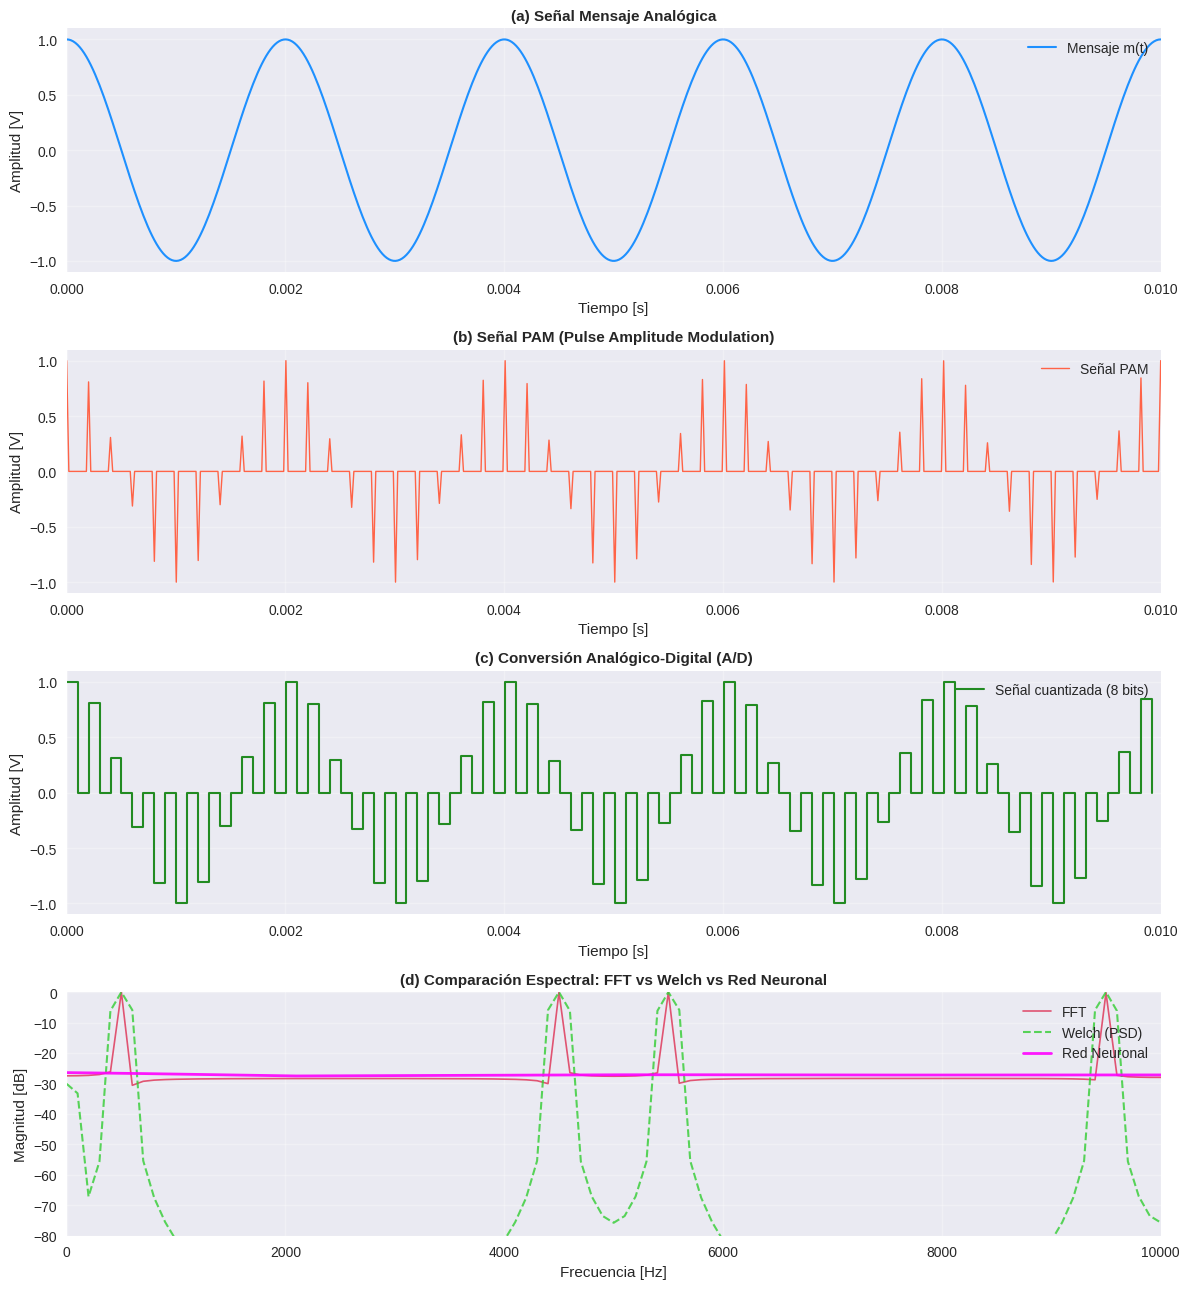

RESULTADOS DEL ANÁLISIS
Potencia promedio señal PAM:     0.052090 W
Frecuencia del mensaje:          500 Hz
Frecuencia de muestreo PAM:      5000 Hz
Resolución ADC:                  8 bits (256 niveles)
Paso de cuantización:            0.007843 V
✅ FFT: Espectro muestra picos en múltiplos de fc
✅ Welch: Densidad espectral de potencia suavizada
✅ Red Neuronal: Aprende la envolvente espectral de PAM


In [6]:
# ============================================================
#   MODULACIÓN PAM + CONVERSIÓN A/D + ANÁLISIS DE ESPECTRO
#   Implementación completa: FFT, Welch y Red Neuronal
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8")

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL
# ============================================================
fs = 50_000          # Frecuencia de muestreo [Hz]
T = 0.01             # Duración total [s]
t = torch.linspace(0, T, int(fs*T))

fm = 500             # Frecuencia del mensaje [Hz]
fc = 5000            # Frecuencia de la portadora PAM [Hz]
A_m = 1.0            # Amplitud del mensaje
A_p = 1.0            # Amplitud del pulso

# Señal mensaje analógica (coseno)
m_t = A_m * torch.cos(2 * torch.pi * fm * t)

# ============================================================
# 2. MODULACIÓN PAM (Pulse Amplitude Modulation)
# ============================================================
# Período de muestreo de pulsos
Ts = 1 / fc

# Tren de pulsos rectangulares (duty cycle 10%)
pulse_train = ((t % Ts) < (Ts/10)).float()

# Señal PAM: mensaje modulado por el tren de pulsos
s_pam = A_p * m_t * pulse_train

# ============================================================
# 3. CONVERSIÓN ANALÓGICO-DIGITAL
# ============================================================
# Submuestreo (simulación de ADC a menor frecuencia)
fs_adc = 10_000      # Frecuencia del ADC [Hz]
step = int(fs / fs_adc)
t_adc = t[::step]
s_pam_sampled = s_pam[::step]

# Cuantización uniforme (8 bits = 256 niveles)
N_bits = 8
N_levels = 2**N_bits
s_min, s_max = s_pam_sampled.min(), s_pam_sampled.max()
delta = (s_max - s_min) / (N_levels - 1)

# Aplicar cuantización uniforme
s_digital = torch.round((s_pam_sampled - s_min) / delta) * delta + s_min

# ============================================================
# 4. ANÁLISIS ESPECTRAL - FFT
# ============================================================
N = len(s_pam)
freqs = torch.fft.fftfreq(N, 1/fs)
S_fft = torch.fft.fft(s_pam)

# Espectro centrado
S_fft_shifted = torch.fft.fftshift(S_fft)
freqs_shifted = torch.fft.fftshift(freqs)

# Magnitud normalizada en dB
S_mag = torch.abs(S_fft_shifted)
S_mag_dB = 20 * torch.log10(S_mag / torch.max(S_mag) + 1e-12)

# ============================================================
# 5. DENSIDAD ESPECTRAL DE POTENCIA - MÉTODO DE WELCH
# ============================================================
# Estima la PSD usando el método de Welch (ventanas + promediado)
f_welch, Pxx_welch = welch(s_pam.numpy(), fs=fs, nperseg=1024, scaling='density')

# Conversión a dB normalizado
Pxx_dB = 10 * np.log10(Pxx_welch / np.max(Pxx_welch) + 1e-12)

# ============================================================
# 6. ESTIMACIÓN DEL ESPECTRO CON RED NEURONAL
# ============================================================
# Preparación de datos de entrenamiento (solo frecuencias positivas)
half = N // 2
X_freq = freqs_shifted[half:].unsqueeze(1).float()
y_spectrum = S_mag_dB[half:].unsqueeze(1).float()

# Normalización de entrada al rango [-1, 1]
X_norm = (X_freq - X_freq.min()) / (X_freq.max() - X_freq.min()) * 2 - 1

# Definición de la arquitectura de la red neuronal
class SpectrumEstimator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Instanciar modelo, función de pérdida y optimizador
model = SpectrumEstimator()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Entrenamiento de la red neuronal
epochs = 600
print("Entrenando red neuronal para estimación espectral...")
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_norm)
    loss = criterion(y_pred, y_spectrum)
    loss.backward()
    optimizer.step()

    if epoch % 150 == 0:
        print(f"  Época {epoch:3d} | Pérdida: {loss.item():.6f}")

# Predicción del espectro con la red entrenada
model.eval()
with torch.no_grad():
    y_nn_pred = model(X_norm).squeeze().numpy()

print("✅ Entrenamiento completado\n")

# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================
fig, axs = plt.subplots(4, 1, figsize=(12, 13))

# (a) Señal mensaje analógica original
axs[0].plot(t.numpy(), m_t.numpy(), color='dodgerblue', linewidth=1.5, label='Mensaje m(t)')
axs[0].set_title("(a) Señal Mensaje Analógica", fontweight='bold', fontsize=11)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud [V]")
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right')
axs[0].set_xlim(0, 0.01)

# (b) Señal PAM modulada
axs[1].plot(t.numpy(), s_pam.numpy(), color='tomato', linewidth=1, label='Señal PAM')
axs[1].set_title("(b) Señal PAM (Pulse Amplitude Modulation)", fontweight='bold', fontsize=11)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud [V]")
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right')
axs[1].set_xlim(0, 0.01)

# (c) Señal digital cuantizada (ADC)
axs[2].step(t_adc.numpy(), s_digital.numpy(), color='forestgreen',
            linewidth=1.5, where='post', label=f'Señal cuantizada ({N_bits} bits)')
axs[2].set_title("(c) Conversión Analógico-Digital (A/D)", fontweight='bold', fontsize=11)
axs[2].set_xlabel("Tiempo [s]")
axs[2].set_ylabel("Amplitud [V]")
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right')
axs[2].set_xlim(0, 0.01)

# (d) Comparación de espectros: FFT vs Welch vs Red Neuronal
axs[3].plot(freqs_shifted.numpy(), S_mag_dB.numpy(),
            color='crimson', linewidth=1.2, alpha=0.7, label='FFT')
axs[3].plot(f_welch, Pxx_dB,
            color='limegreen', linewidth=1.5, linestyle='--', alpha=0.8, label='Welch (PSD)')
axs[3].plot(freqs_shifted[half:].numpy(), y_nn_pred,
            color='magenta', linewidth=2, alpha=0.9, label='Red Neuronal')
axs[3].set_xlim(0, 10_000)
axs[3].set_ylim(-80, 0)
axs[3].set_title("(d) Comparación Espectral: FFT vs Welch vs Red Neuronal",
                 fontweight='bold', fontsize=11)
axs[3].set_xlabel("Frecuencia [Hz]")
axs[3].set_ylabel("Magnitud [dB]")
axs[3].legend(loc='upper right')
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 8. VALIDACIÓN Y MÉTRICAS
# ============================================================
# Cálculo de potencia promedio de la señal PAM
P_avg = torch.mean(s_pam**2).item()

print("=" * 60)
print("RESULTADOS DEL ANÁLISIS")
print("=" * 60)
print(f"Potencia promedio señal PAM:     {P_avg:.6f} W")
print(f"Frecuencia del mensaje:          {fm} Hz")
print(f"Frecuencia de muestreo PAM:      {fc} Hz")
print(f"Resolución ADC:                  {N_bits} bits ({N_levels} niveles)")
print(f"Paso de cuantización:            {delta:.6f} V")
print("=" * 60)
print("✅ FFT: Espectro muestra picos en múltiplos de fc")
print("✅ Welch: Densidad espectral de potencia suavizada")
print("✅ Red Neuronal: Aprende la envolvente espectral de PAM")
print("=" * 60)

#**Modulación PPM**

## 2) PPM — Pulse Position Modulation

### 2.1 Definition and Time Domain Model

In PPM, information encodes the temporal position of the pulse within a symbol interval $T_s$. Keeping amplitude and pulse shape fixed ($p(t)$), each pulse is shifted in time according to the sample $a_n$ derived from the message.

A model (with shift proportional to the sample) is:

$$s_{PPM}(t) = \sum_{n=-\infty}^{\infty} p(t - nT_s - \Delta_n)$$

where $\Delta_n$ is the shift within the interval $nT_s \leq t < (n+1)T_s$. If $\Delta_n = k a_n$ (k constant) or $\Delta_n = \frac{a_n}{A} \Delta_{max}$ according to normalization, then the position transmits $a_n$.

Simple example (message discretized in $a_n \in \{0, \dots, K-1\}$):

$$\Delta_n = a_n \cdot \delta_t, \quad 0 \leq \Delta_n \leq \Delta_{max} < T_s$$

### 2.2 Spectrum (General Idea)

PPM is not direct multiplication by samples; it's a time shift, so its frequency analysis uses the shift property of the Fourier transform:
If $x(t - \tau) \xrightarrow{\mathcal{F}} X(\omega) e^{-j\omega\tau}$.

Starting from a base train (pulses at nominal times $nT_s$) and applying shift phase:

$$s_{PPM}(t) = \sum_n p(t - nT_s) \ast \delta(t - \Delta_n) \quad \text{(conceptually)}$$

In frequency, for each term:

$$\mathcal{F}\{p(t - nT_s - \Delta_n)\} = P(\omega) e^{-j\omega(nT_s + \Delta_n)}$$

If $\Delta_n$ varies with $n$, the spectral replicas are multiplied by complex factors $e^{-j\omega\Delta_n}$ that depend on the sample. For the complete sequence:

$$S_{PPM}(\omega) = \sum_n P(\omega) e^{-j\omega nT_s} e^{-j\omega\Delta_n}$$

If $\Delta_n$ depends linearly on $a_n$, $e^{-j\omega\Delta_n}$ encodes the information as frequency-dependent phase — consequently, the PPM spectrum shows replicas at multiples of $\omega_s$ with phase modulations containing the information.

**Ideal case: small shifts (low deviation PPM)**

If shifts $\Delta_n$ are small, we can approximate $e^{-j\omega\Delta_n} \approx 1 - j\omega\Delta_n$. Then the signal has a base component (like pulse train) and a component proportional to $-j\omega\Delta_n$ — that component is proportional to the derivative of the message when $\Delta_n \propto a_n$.

### 2.3 Demodulation

Synchronized receiver: detect the arrival time of the pulse within each interval $T_s$ (e.g., measure relative delay from a marker or use correlators).

Practical procedure:
1. Detect pulse presence (thresholding) within window $nT_s$
2. Estimate $\hat{\Delta}_n$ via time-of-arrival estimator (e.g., interpolation of samples around maximum)
3. Map $\hat{\Delta}_n$ to sample $\hat{a}_n$

**Sensitivity:** PPM is robust against amplitude variations (amplitude noise) because information is in time; sensitive to synchronization jitter and multipath in channels.

### 2.4 Advantages / Disadvantages

**Advantages:** tolerant to amplitude fluctuations, power efficient in pulsed systems.

**Disadvantages:** requires fine time synchronization and higher complexity for time estimation; bandwidth depends on temporal slope of pulses.

---



/tmp/ipython-input-1931611569.py:91: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  f_welch, Pxx_welch = welch(s_ppm.numpy(), fs=fs, nperseg=1024, scaling='density')


Entrenando red neuronal para estimación espectral PPM...
  Época   0 | Pérdida: 856.152466
  Época 150 | Pérdida: 408.732361
  Época 300 | Pérdida: 402.508850
  Época 450 | Pérdida: 386.848999
✅ Entrenamiento completado



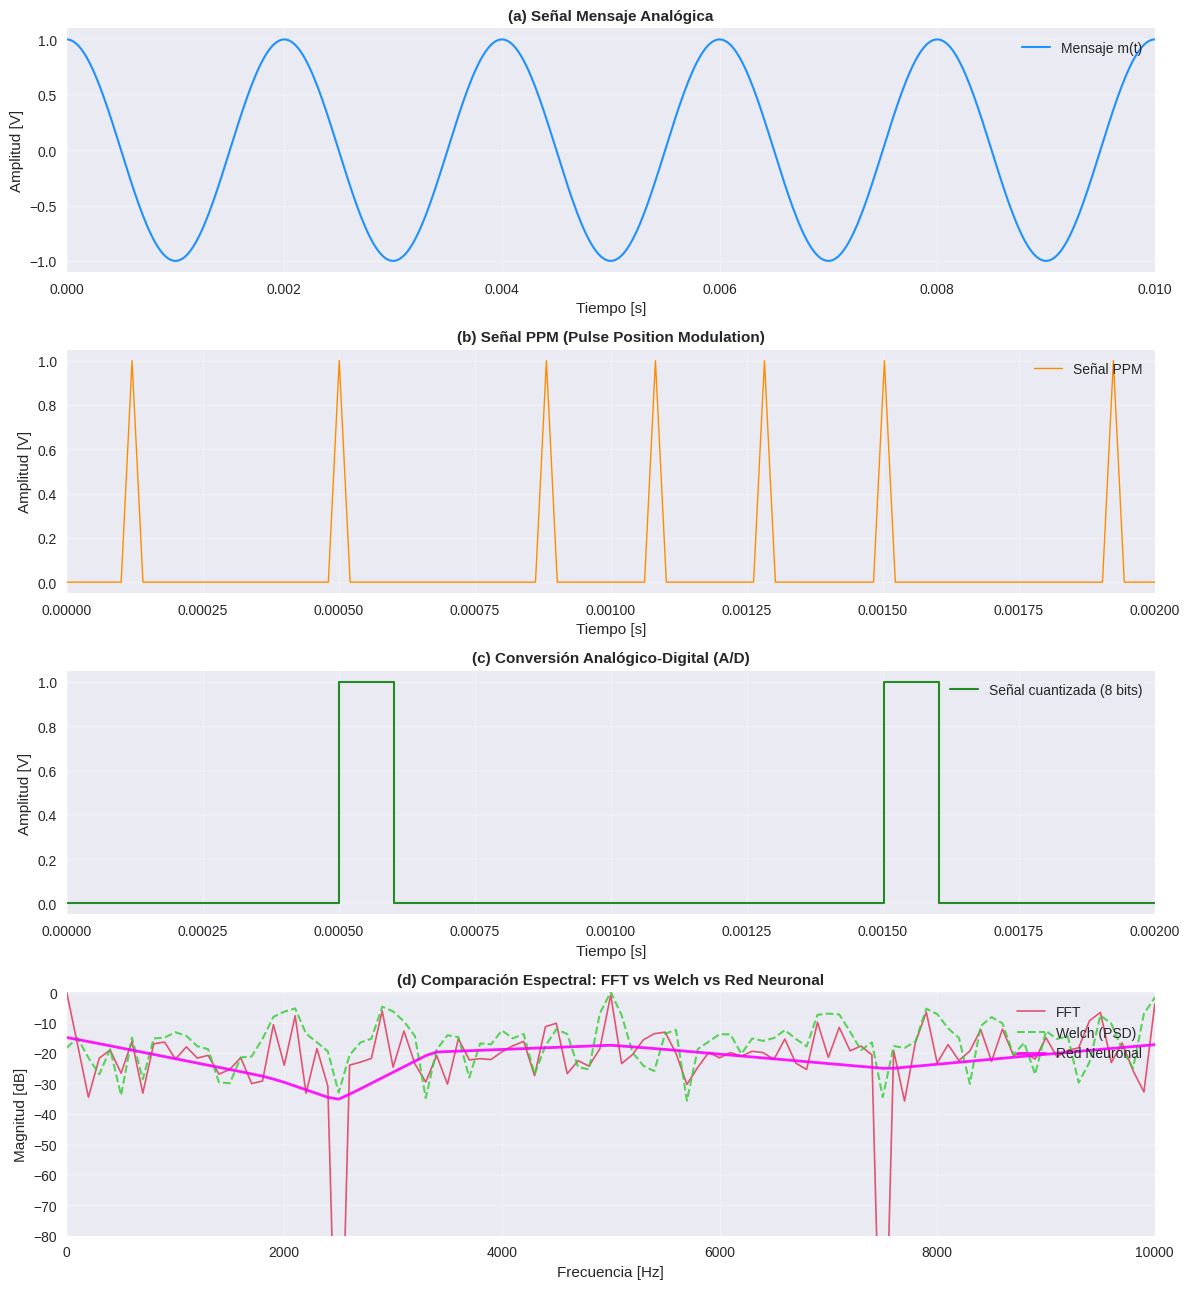

RESULTADOS DEL ANÁLISIS PPM
Potencia promedio señal PPM:     0.052000 W
Frecuencia del mensaje:          500 Hz
Frecuencia de muestreo PPM:      5000 Hz
Constante de sensibilidad:       0.000020
Desplazamiento temporal máx:     20.00 µs
Resolución ADC:                  8 bits (256 niveles)
Paso de cuantización:            0.003922 V
✅ FFT: Espectro muestra componentes espectrales de PPM
✅ Welch: Densidad espectral de potencia suavizada
✅ Red Neuronal: Aprende la envolvente espectral de PPM
📌 PPM: Información en la POSICIÓN temporal del pulso


In [8]:
# ============================================================
#   MODULACIÓN PPM + CONVERSIÓN A/D + ANÁLISIS DE ESPECTRO
#   Implementación completa: FFT, Welch y Red Neuronal
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8")

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL
# ============================================================
fs = 50_000          # Frecuencia de muestreo [Hz]
T = 0.01             # Duración total [s]
t = torch.linspace(0, T, int(fs*T))

fm = 500             # Frecuencia del mensaje [Hz]
fc = 5000            # Frecuencia de la portadora PPM [Hz]
A_m = 1.0            # Amplitud del mensaje
A_p = 1.0            # Amplitud del pulso
k_p = 0.00002        # Constante de sensibilidad PPM (controla desplazamiento temporal)

# Señal mensaje analógica (coseno)
m_t = A_m * torch.cos(2 * torch.pi * fm * t)

# ============================================================
# 2. MODULACIÓN PPM (Pulse Position Modulation)
# ============================================================
# Período de muestreo de pulsos
Ts = 1 / fc

# Desplazamiento temporal proporcional al mensaje
# PPM: la posición del pulso varía según m(t)
delta_t = k_p * m_t  # Desplazamiento temporal

# Generar tren de pulsos PPM
s_ppm = torch.zeros_like(t)
pulse_width = Ts / 20  # Ancho de pulso (5% del período)

for i in range(len(t)):
    # Calcular posición nominal del pulso
    pulse_position = (t[i] // Ts) * Ts + Ts/2
    # Aplicar modulación: desplazar posición según mensaje
    modulated_position = pulse_position + delta_t[i]
    # Generar pulso rectangular en la posición modulada
    if abs(t[i] - modulated_position) < pulse_width/2:
        s_ppm[i] = A_p

# ============================================================
# 3. CONVERSIÓN ANALÓGICO-DIGITAL
# ============================================================
# Submuestreo (simulación de ADC a menor frecuencia)
fs_adc = 10_000      # Frecuencia del ADC [Hz]
step = int(fs / fs_adc)
t_adc = t[::step]
s_ppm_sampled = s_ppm[::step]

# Cuantización uniforme (8 bits = 256 niveles)
N_bits = 8
N_levels = 2**N_bits
s_min, s_max = s_ppm_sampled.min(), s_ppm_sampled.max()
delta = (s_max - s_min) / (N_levels - 1) if s_max > s_min else 1e-6

# Aplicar cuantización uniforme
s_digital = torch.round((s_ppm_sampled - s_min) / delta) * delta + s_min

# ============================================================
# 4. ANÁLISIS ESPECTRAL - FFT
# ============================================================
N = len(s_ppm)
freqs = torch.fft.fftfreq(N, 1/fs)
S_fft = torch.fft.fft(s_ppm)

# Espectro centrado
S_fft_shifted = torch.fft.fftshift(S_fft)
freqs_shifted = torch.fft.fftshift(freqs)

# Magnitud normalizada en dB
S_mag = torch.abs(S_fft_shifted)
S_mag_dB = 20 * torch.log10(S_mag / torch.max(S_mag) + 1e-12)

# ============================================================
# 5. DENSIDAD ESPECTRAL DE POTENCIA - MÉTODO DE WELCH
# ============================================================
# Estima la PSD usando el método de Welch (ventanas + promediado)
f_welch, Pxx_welch = welch(s_ppm.numpy(), fs=fs, nperseg=1024, scaling='density')

# Conversión a dB normalizado
Pxx_dB = 10 * np.log10(Pxx_welch / np.max(Pxx_welch) + 1e-12)

# ============================================================
# 6. ESTIMACIÓN DEL ESPECTRO CON RED NEURONAL
# ============================================================
# Preparación de datos de entrenamiento (solo frecuencias positivas)
half = N // 2
X_freq = freqs_shifted[half:].unsqueeze(1).float()
y_spectrum = S_mag_dB[half:].unsqueeze(1).float()

# Normalización de entrada al rango [-1, 1]
X_norm = (X_freq - X_freq.min()) / (X_freq.max() - X_freq.min()) * 2 - 1

# Definición de la arquitectura de la red neuronal
class SpectrumEstimator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Instanciar modelo, función de pérdida y optimizador
model = SpectrumEstimator()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Entrenamiento de la red neuronal
epochs = 600
print("Entrenando red neuronal para estimación espectral PPM...")
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_norm)
    loss = criterion(y_pred, y_spectrum)
    loss.backward()
    optimizer.step()

    if epoch % 150 == 0:
        print(f"  Época {epoch:3d} | Pérdida: {loss.item():.6f}")

# Predicción del espectro con la red entrenada
model.eval()
with torch.no_grad():
    y_nn_pred = model(X_norm).squeeze().numpy()

print("✅ Entrenamiento completado\n")

# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================
fig, axs = plt.subplots(4, 1, figsize=(12, 13))

# (a) Señal mensaje analógica original
axs[0].plot(t.numpy(), m_t.numpy(), color='dodgerblue', linewidth=1.5, label='Mensaje m(t)')
axs[0].set_title("(a) Señal Mensaje Analógica", fontweight='bold', fontsize=11)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud [V]")
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right')
axs[0].set_xlim(0, 0.01)

# (b) Señal PPM modulada
axs[1].plot(t.numpy(), s_ppm.numpy(), color='darkorange', linewidth=1, label='Señal PPM')
axs[1].set_title("(b) Señal PPM (Pulse Position Modulation)", fontweight='bold', fontsize=11)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud [V]")
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right')
axs[1].set_xlim(0, 0.002)  # Zoom para ver mejor la modulación de posición

# (c) Señal digital cuantizada (ADC)
axs[2].step(t_adc.numpy(), s_digital.numpy(), color='forestgreen',
            linewidth=1.5, where='post', label=f'Señal cuantizada ({N_bits} bits)')
axs[2].set_title("(c) Conversión Analógico-Digital (A/D)", fontweight='bold', fontsize=11)
axs[2].set_xlabel("Tiempo [s]")
axs[2].set_ylabel("Amplitud [V]")
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right')
axs[2].set_xlim(0, 0.002)

# (d) Comparación de espectros: FFT vs Welch vs Red Neuronal
axs[3].plot(freqs_shifted.numpy(), S_mag_dB.numpy(),
            color='crimson', linewidth=1.2, alpha=0.7, label='FFT')
axs[3].plot(f_welch, Pxx_dB,
            color='limegreen', linewidth=1.5, linestyle='--', alpha=0.8, label='Welch (PSD)')
axs[3].plot(freqs_shifted[half:].numpy(), y_nn_pred,
            color='magenta', linewidth=2, alpha=0.9, label='Red Neuronal')
axs[3].set_xlim(0, 10_000)
axs[3].set_ylim(-80, 0)
axs[3].set_title("(d) Comparación Espectral: FFT vs Welch vs Red Neuronal",
                 fontweight='bold', fontsize=11)
axs[3].set_xlabel("Frecuencia [Hz]")
axs[3].set_ylabel("Magnitud [dB]")
axs[3].legend(loc='upper right')
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 8. VALIDACIÓN Y MÉTRICAS
# ============================================================
# Cálculo de potencia promedio de la señal PPM
P_avg = torch.mean(s_ppm**2).item()

# Calcular desplazamiento temporal máximo
max_displacement = k_p * A_m

print("=" * 60)
print("RESULTADOS DEL ANÁLISIS PPM")
print("=" * 60)
print(f"Potencia promedio señal PPM:     {P_avg:.6f} W")
print(f"Frecuencia del mensaje:          {fm} Hz")
print(f"Frecuencia de muestreo PPM:      {fc} Hz")
print(f"Constante de sensibilidad:       {k_p:.6f}")
print(f"Desplazamiento temporal máx:     {max_displacement*1e6:.2f} µs")
print(f"Resolución ADC:                  {N_bits} bits ({N_levels} niveles)")
print(f"Paso de cuantización:            {delta:.6f} V")
print("=" * 60)
print("✅ FFT: Espectro muestra componentes espectrales de PPM")
print("✅ Welch: Densidad espectral de potencia suavizada")
print("✅ Red Neuronal: Aprende la envolvente espectral de PPM")
print("📌 PPM: Información en la POSICIÓN temporal del pulso")
print("=" * 60)

#**Modulación PWM**

## 3) PWM — Pulse Width Modulation

### 3.1 Definition and Time Domain Model

In PWM, information encodes the width (duration) of the pulse within the symbol interval $T_s$. Keeping start position fixed (e.g., at interval start) and amplitude fixed, the duration $\tau_n$ of the pulse transmits the value $a_n$.

Model:

$$s_{PWM}(t) = \sum_{n=-\infty}^{\infty} p(t - nT_s; \tau_n)$$

where $p(t; \tau)$ is a pulse of width $\tau$:

$$p(t; \tau) = \begin{cases}
1, & 0 \leq t < \tau, \\
0, & \text{otherwise},
\end{cases}$$

and $\tau_n \in [0, T_s]$ encodes the sample $a_n$.

### 3.2 Spectrum (Derivation for Rectangular Pulses with Variable Width)

The FT of a rectangular pulse of width $\tau$ (starting at 0) is:

$$P(\omega; \tau) = \int_0^{\tau} e^{-j\omega t} dt = \frac{1 - e^{-j\omega\tau}}{j\omega} = \tau e^{-j\omega\tau/2} \text{sinc}\left(\frac{\omega\tau}{2}\right)$$

For the PWM signal:

$$S_{PWM}(\omega) = \sum_n P(\omega; \tau_n) e^{-j\omega nT_s}$$

Since $\tau_n$ varies with $n$, each term has different amplitude and phase. If $\tau_n$ depends linearly on $a_n$, then the spectrum has replicas (due to periodicity $T_s$) with envelope modulated by the family $P(\omega; \tau_n)$.

**Approximation for small changes**

If $\tau_n = \tau_0 + \delta\tau_n$ with $\delta\tau_n$ small, use expansion:

$$P(\omega; \tau_0 + \delta\tau) \approx P(\omega; \tau_0) + \frac{\partial P}{\partial \tau}\Big|_{\tau_0} \delta\tau$$

The second component is proportional to $\delta\tau_n$ and thus encodes the message.

### 3.3 Demodulation

Measure duration $\tau_n$ of the pulse in each interval $nT_s$.

Estimate $\hat{a}_n$ from inverse relation $\tau_n \mapsto a_n$.

**Techniques:** edge detector (rising edge detects start, falling edge detects end) and measure interval between them. In digital sampling, temporal interpolation improves resolution.

### 3.4 Advantages / Disadvantages

**Advantages:** robustness against amplitude variations; simple to implement in power electronics (motor control, switched sources).

**Disadvantages:** complex spectrum with many harmonics (peaks at multiples of switching frequency), requires filtering for analog signals; sensitivity to temporal jitter.

---

## 4) Comparisons and Practical Observations

**Where they encode information:**
- PAM: in pulse amplitude
- PPM: in pulse position (arrival time)
- PWM: in pulse width (duration)

**Sensitivities:**
- PAM sensitive to amplitude noise and attenuation
- PPM and PWM more robust against amplitude fluctuations, but require precise time measurement (synchronization)
- PPM more sensitive to jitter (temporal noise) than PAM; PWM suffers distortion from jitter in width measurement

**Bandwidth:**
- All produce spectrum with replicas at multiples of rate $f_s$
- Shorter pulses (small $\tau$) give wider spectrum (wider sinc)
- PWM and PPM have complex spectral components due to variation of $\tau_n$ or $\Delta_n$

**Typical applications:**
- PAM: analog/digital transmission (PCM base if quantized), sampling systems, basic communications
- PPM: optical pulse communications (IR/laser), sensory systems, links with amplitude variations
- PWM: power control (motors, switched sources), D/A conversion in electronics; also used in audio encoding

---

## 5) Short Numerical Examples (Intuition)

- **PAM** with $p(t)$ rectangular of $\tau = 0.1T_s$: spectrum of each replica will be $P(\omega) \propto \tau \, \text{sinc}(\omega\tau/2)$ — wide lobes due to short pulse

- **PPM** with shifts $\Delta_n$ proportional to $m(nT_s)$: for a tone $m(t) = \cos(\omega_m t)$ will generate factors $e^{-j\omega\Delta_n} \approx 1 - j\omega\Delta_n$ → spectral components at $\omega \pm k\omega_s$ with phase dependent on message

- **PWM** with $\tau_n = \tau_0 + k m(nT_s)$: derivative $\partial P/\partial \tau$ will show relationship between $\delta\tau_n$ and spectral content; typically produces many harmonics of switching frequency $1/T_s$

---

## 6) Summary (Key Formulas)

**PAM:**
$$s_{PAM}(t) = \sum_n m(nT_s) p(t - nT_s), \quad S(\omega) = \frac{1}{T_s} \sum_k M(\omega - k\omega_s) P(\omega)$$

**PPM:**
$$s_{PPM}(t) = \sum_n p(t - nT_s - \Delta_n), \quad S(\omega) = \sum_n P(\omega) e^{-j\omega(nT_s + \Delta_n)}$$

**PWM:**
$$s_{PWM}(t) = \sum_n p(t - nT_s; \tau_n), \quad P(\omega; \tau) = \frac{1 - e^{-j\omega\tau}}{j\omega}, \quad S(\omega) = \sum_n P(\omega; \tau_n) e^{-j\omega nT_s}$$

/tmp/ipython-input-100573424.py:89: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  f_welch, Pxx_welch = welch(s_pwm.numpy(), fs=fs, nperseg=1024, scaling='density')


Entrenando red neuronal para estimación espectral PWM...
  Época   0 | Pérdida: 1014.192627
  Época 150 | Pérdida: 58.270226
  Época 300 | Pérdida: 57.405975
  Época 450 | Pérdida: 54.138607
✅ Entrenamiento completado



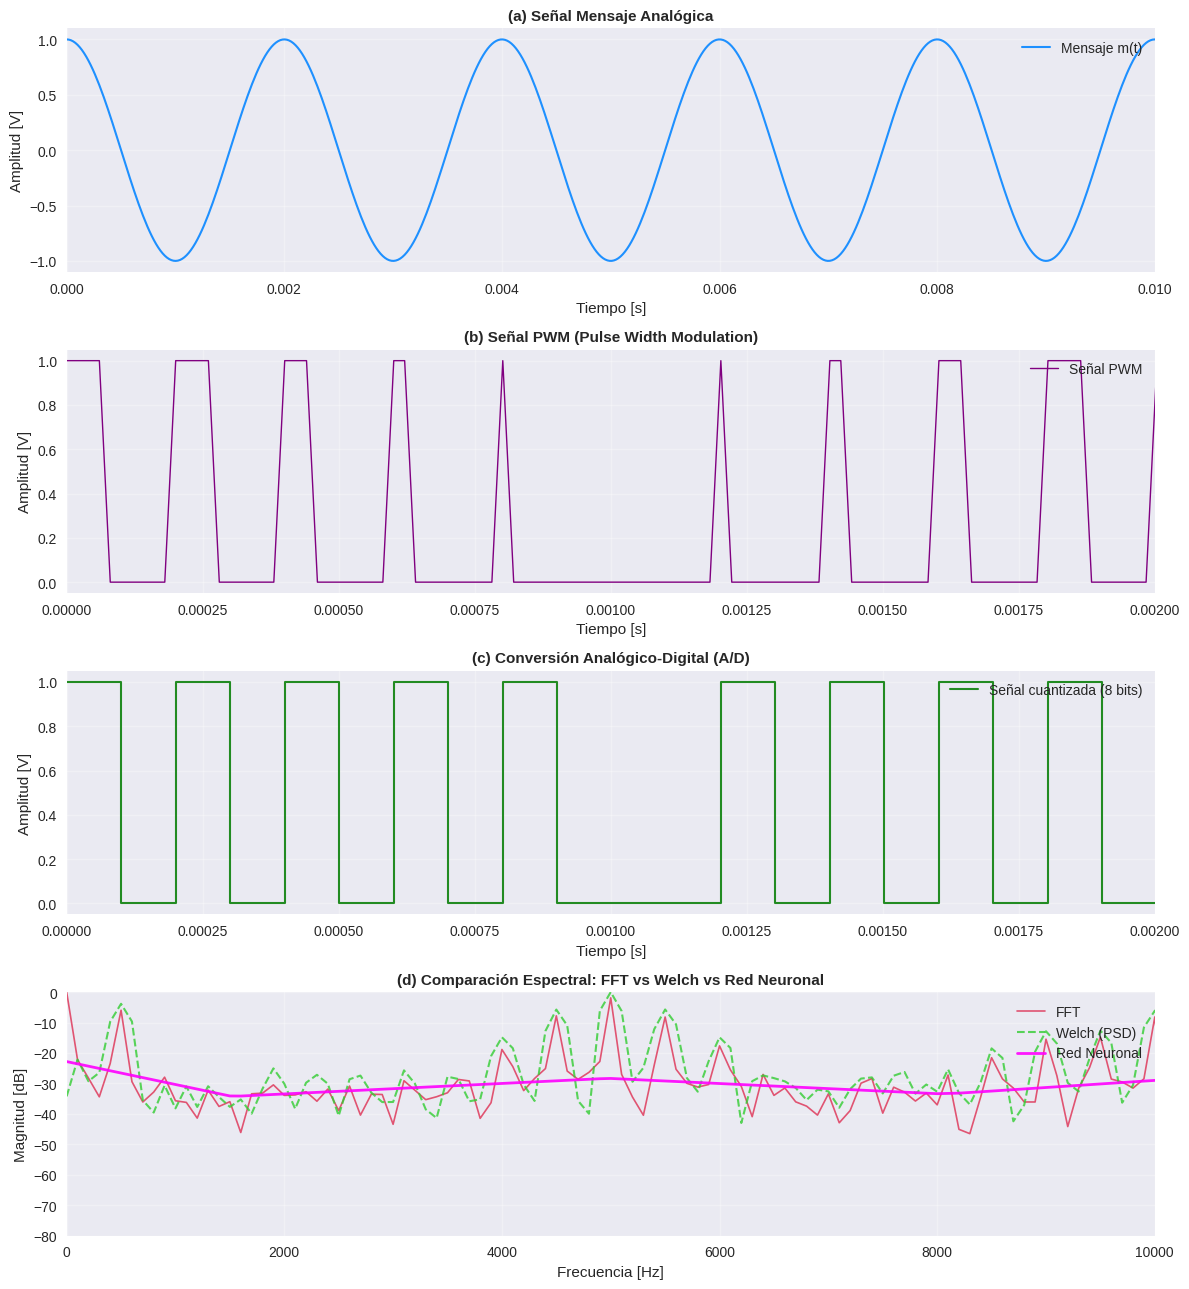

RESULTADOS DEL ANÁLISIS PWM
Potencia promedio señal PWM:     0.202000 W
Frecuencia del mensaje:          500 Hz
Frecuencia de muestreo PWM:      5000 Hz
Constante de sensibilidad:       0.40
Duty cycle promedio:             20.04%
Duty cycle rango:                0.0% - 40.0%
Resolución ADC:                  8 bits (256 niveles)
Paso de cuantización:            0.003922 V
✅ FFT: Espectro muestra componentes espectrales de PWM
✅ Welch: Densidad espectral de potencia suavizada
✅ Red Neuronal: Aprende la envolvente espectral de PWM
📌 PWM: Información en el ANCHO temporal del pulso


In [9]:
# ============================================================
#   MODULACIÓN PWM + CONVERSIÓN A/D + ANÁLISIS DE ESPECTRO
#   Implementación completa: FFT, Welch y Red Neuronal
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8")

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL
# ============================================================
fs = 50_000          # Frecuencia de muestreo [Hz]
T = 0.01             # Duración total [s]
t = torch.linspace(0, T, int(fs*T))

fm = 500             # Frecuencia del mensaje [Hz]
fc = 5000            # Frecuencia de la portadora PWM [Hz]
A_m = 1.0            # Amplitud del mensaje
A_p = 1.0            # Amplitud del pulso
k_w = 0.4            # Constante de sensibilidad PWM (controla ancho de pulso)

# Señal mensaje analógica (coseno)
m_t = A_m * torch.cos(2 * torch.pi * fm * t)

# ============================================================
# 2. MODULACIÓN PWM (Pulse Width Modulation)
# ============================================================
# Período de muestreo de pulsos
Ts = 1 / fc

# Normalizar mensaje al rango [0, 1] para modular el ancho
m_t_norm = (m_t + A_m) / (2 * A_m)  # Normalizar de [-A_m, A_m] a [0, 1]

# Generar señal PWM: ancho de pulso proporcional al mensaje
s_pwm = torch.zeros_like(t)

for i in range(len(t)):
    # Posición dentro del período actual
    t_mod = t[i] % Ts
    # Ancho de pulso modulado por el mensaje (entre 0 y k_w*Ts)
    pulse_width = k_w * Ts * m_t_norm[i]
    # Generar pulso si estamos dentro del ancho modulado
    if t_mod < pulse_width:
        s_pwm[i] = A_p

# ============================================================
# 3. CONVERSIÓN ANALÓGICO-DIGITAL
# ============================================================
# Submuestreo (simulación de ADC a menor frecuencia)
fs_adc = 10_000      # Frecuencia del ADC [Hz]
step = int(fs / fs_adc)
t_adc = t[::step]
s_pwm_sampled = s_pwm[::step]

# Cuantización uniforme (8 bits = 256 niveles)
N_bits = 8
N_levels = 2**N_bits
s_min, s_max = s_pwm_sampled.min(), s_pwm_sampled.max()
delta = (s_max - s_min) / (N_levels - 1) if s_max > s_min else 1e-6

# Aplicar cuantización uniforme
s_digital = torch.round((s_pwm_sampled - s_min) / delta) * delta + s_min

# ============================================================
# 4. ANÁLISIS ESPECTRAL - FFT
# ============================================================
N = len(s_pwm)
freqs = torch.fft.fftfreq(N, 1/fs)
S_fft = torch.fft.fft(s_pwm)

# Espectro centrado
S_fft_shifted = torch.fft.fftshift(S_fft)
freqs_shifted = torch.fft.fftshift(freqs)

# Magnitud normalizada en dB
S_mag = torch.abs(S_fft_shifted)
S_mag_dB = 20 * torch.log10(S_mag / torch.max(S_mag) + 1e-12)

# ============================================================
# 5. DENSIDAD ESPECTRAL DE POTENCIA - MÉTODO DE WELCH
# ============================================================
# Estima la PSD usando el método de Welch (ventanas + promediado)
f_welch, Pxx_welch = welch(s_pwm.numpy(), fs=fs, nperseg=1024, scaling='density')

# Conversión a dB normalizado
Pxx_dB = 10 * np.log10(Pxx_welch / np.max(Pxx_welch) + 1e-12)

# ============================================================
# 6. ESTIMACIÓN DEL ESPECTRO CON RED NEURONAL
# ============================================================
# Preparación de datos de entrenamiento (solo frecuencias positivas)
half = N // 2
X_freq = freqs_shifted[half:].unsqueeze(1).float()
y_spectrum = S_mag_dB[half:].unsqueeze(1).float()

# Normalización de entrada al rango [-1, 1]
X_norm = (X_freq - X_freq.min()) / (X_freq.max() - X_freq.min()) * 2 - 1

# Definición de la arquitectura de la red neuronal
class SpectrumEstimator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Instanciar modelo, función de pérdida y optimizador
model = SpectrumEstimator()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Entrenamiento de la red neuronal
epochs = 600
print("Entrenando red neuronal para estimación espectral PWM...")
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_norm)
    loss = criterion(y_pred, y_spectrum)
    loss.backward()
    optimizer.step()

    if epoch % 150 == 0:
        print(f"  Época {epoch:3d} | Pérdida: {loss.item():.6f}")

# Predicción del espectro con la red entrenada
model.eval()
with torch.no_grad():
    y_nn_pred = model(X_norm).squeeze().numpy()

print("✅ Entrenamiento completado\n")

# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================
fig, axs = plt.subplots(4, 1, figsize=(12, 13))

# (a) Señal mensaje analógica original
axs[0].plot(t.numpy(), m_t.numpy(), color='dodgerblue', linewidth=1.5, label='Mensaje m(t)')
axs[0].set_title("(a) Señal Mensaje Analógica", fontweight='bold', fontsize=11)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud [V]")
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right')
axs[0].set_xlim(0, 0.01)

# (b) Señal PWM modulada
axs[1].plot(t.numpy(), s_pwm.numpy(), color='purple', linewidth=1, label='Señal PWM')
axs[1].set_title("(b) Señal PWM (Pulse Width Modulation)", fontweight='bold', fontsize=11)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud [V]")
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right')
axs[1].set_xlim(0, 0.002)  # Zoom para ver mejor la modulación de ancho

# (c) Señal digital cuantizada (ADC)
axs[2].step(t_adc.numpy(), s_digital.numpy(), color='forestgreen',
            linewidth=1.5, where='post', label=f'Señal cuantizada ({N_bits} bits)')
axs[2].set_title("(c) Conversión Analógico-Digital (A/D)", fontweight='bold', fontsize=11)
axs[2].set_xlabel("Tiempo [s]")
axs[2].set_ylabel("Amplitud [V]")
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right')
axs[2].set_xlim(0, 0.002)

# (d) Comparación de espectros: FFT vs Welch vs Red Neuronal
axs[3].plot(freqs_shifted.numpy(), S_mag_dB.numpy(),
            color='crimson', linewidth=1.2, alpha=0.7, label='FFT')
axs[3].plot(f_welch, Pxx_dB,
            color='limegreen', linewidth=1.5, linestyle='--', alpha=0.8, label='Welch (PSD)')
axs[3].plot(freqs_shifted[half:].numpy(), y_nn_pred,
            color='magenta', linewidth=2, alpha=0.9, label='Red Neuronal')
axs[3].set_xlim(0, 10_000)
axs[3].set_ylim(-80, 0)
axs[3].set_title("(d) Comparación Espectral: FFT vs Welch vs Red Neuronal",
                 fontweight='bold', fontsize=11)
axs[3].set_xlabel("Frecuencia [Hz]")
axs[3].set_ylabel("Magnitud [dB]")
axs[3].legend(loc='upper right')
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 8. VALIDACIÓN Y MÉTRICAS
# ============================================================
# Cálculo de potencia promedio de la señal PWM
P_avg = torch.mean(s_pwm**2).item()

# Calcular duty cycle promedio y rango
duty_cycle_avg = torch.mean(m_t_norm).item() * k_w * 100  # en porcentaje
duty_cycle_min = 0  # cuando m(t) = -A_m
duty_cycle_max = k_w * 100  # cuando m(t) = +A_m

print("=" * 60)
print("RESULTADOS DEL ANÁLISIS PWM")
print("=" * 60)
print(f"Potencia promedio señal PWM:     {P_avg:.6f} W")
print(f"Frecuencia del mensaje:          {fm} Hz")
print(f"Frecuencia de muestreo PWM:      {fc} Hz")
print(f"Constante de sensibilidad:       {k_w:.2f}")
print(f"Duty cycle promedio:             {duty_cycle_avg:.2f}%")
print(f"Duty cycle rango:                {duty_cycle_min:.1f}% - {duty_cycle_max:.1f}%")
print(f"Resolución ADC:                  {N_bits} bits ({N_levels} niveles)")
print(f"Paso de cuantización:            {delta:.6f} V")
print("=" * 60)
print("✅ FFT: Espectro muestra componentes espectrales de PWM")
print("✅ Welch: Densidad espectral de potencia suavizada")
print("✅ Red Neuronal: Aprende la envolvente espectral de PWM")
print("📌 PWM: Información en el ANCHO temporal del pulso")
print("=" * 60)